# ShelfCast: from sales forecasts to stock decisions

A reproducible walkthrough of **real recorded sales**, calibrated uncertainty, and a **hypothetical inventory scenario**. The key question is whether lower forecast error also produces a better decision.

Source: Chen (2012), [Online Retail II](https://doi.org/10.24432/C5CG6D), UCI, CC BY 4.0. The full preparation audit is in `data/audit.json`. Run this notebook after installing `.[dev]`.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image
from shelfcast.experiment import source_hash
from shelfcast.features import FEATURES, supervised

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "data/weekly_sales.csv").exists(), "Run from the repository or notebooks directory"
panel = pd.read_csv(ROOT / "data/weekly_sales.csv", dtype={"sku": str}, parse_dates=["week"])
audit = json.loads((ROOT / "data/audit.json").read_text())
display(pd.DataFrame([{"raw_transactions": audit["raw_rows"], "products": panel.sku.nunique(),
                       "weeks": panel.week.nunique(), "product_weeks": len(panel)}]))

,raw_transactions,products,weeks,product_weeks
0,1067371,50,104,5200


## 1. Verify the information boundary

Changing the forecast week's outcome and every later outcome must leave the forecast inputs unchanged. The next cell demonstrates this property using a real product's sales history.

In [2]:
sku = sorted(panel.sku.unique())[0]
one = panel.loc[panel.sku == sku].copy()
cutoff = pd.Timestamp("2011-09-05")
original = supervised(one, [sku])
changed = one.copy()
changed.loc[changed.week >= cutoff, "units"] += 100000
mutated = supervised(changed, [sku])
pd.testing.assert_frame_equal(original.loc[original.week <= cutoff, FEATURES],
                              mutated.loc[mutated.week <= cutoff, FEATURES])
print("Passed: current/future outcomes cannot change this week's features.")
display(original.loc[original.week == cutoff, ["sku", "week", "units", "lag_1", "mean_4", "annual_lag"]])

Passed: current/future outcomes cannot change this week's features.


,sku,week,units,lag_1,mean_4,annual_lag
83,15036,2011-09-05,155.0,157.0,136.25,2.0


## 2. Run or reuse a matching experiment

Selection, calibration, and testing use separate time blocks. The model is frozen during the test period; the previous week's realized sales may become features for the next forecast. A source-hash check prevents silently reusing output from a different implementation.

In [3]:
output = ROOT / "outputs"
metadata_path = output / "run_metadata.json"
if not metadata_path.exists() or json.loads(metadata_path.read_text())["source_sha256"] != source_hash():
    subprocess.run([sys.executable, "-m", "shelfcast.cli", "reproduce"], cwd=ROOT, check=True)
metadata = json.loads(metadata_path.read_text())
display(pd.DataFrame(metadata["splits"]).T)
forecast = pd.read_csv(output / "forecast_metrics.csv")
display(forecast)
base = forecast.set_index("model").loc["mean_4", "wape"]
model = forecast.set_index("model").loc["deployed", "wape"]
print(f"Relative WAPE reduction versus four-week mean: {1-model/base:.1%}")

Relative WAPE reduction versus four-week mean: 7.6%


,start,end,weeks,rows
train,2010-02-01,2011-04-25,65,3250
validation,2011-05-02,2011-06-27,9,450
calibration,2011-07-04,2011-08-29,9,450
test,2011-09-05,2011-11-28,13,650


,model,mae,wape,bias_units
0,last_week,242.513846,0.690623,-13.713846
1,mean_4,204.857308,0.583386,-24.993462
2,annual_52,362.501538,1.032320,173.950769
3,selected_ml,189.308008,0.539105,-94.162782
4,deployed,189.308008,0.539105,-94.162782


## 3. Accuracy and uncertainty are different questions

An 80% interval is intended to contain a future outcome, not to estimate the uncertainty of an average. Actual coverage and interval width should both be inspected. Temporal and cross-product dependence prevent claiming a standard exchangeability-based coverage guarantee.

,coverage,mean_width,below_lower,above_upper
raw,0.789231,642.630771,0.116923,0.093846
calibrated,0.820000,660.522503,0.087692,0.092308


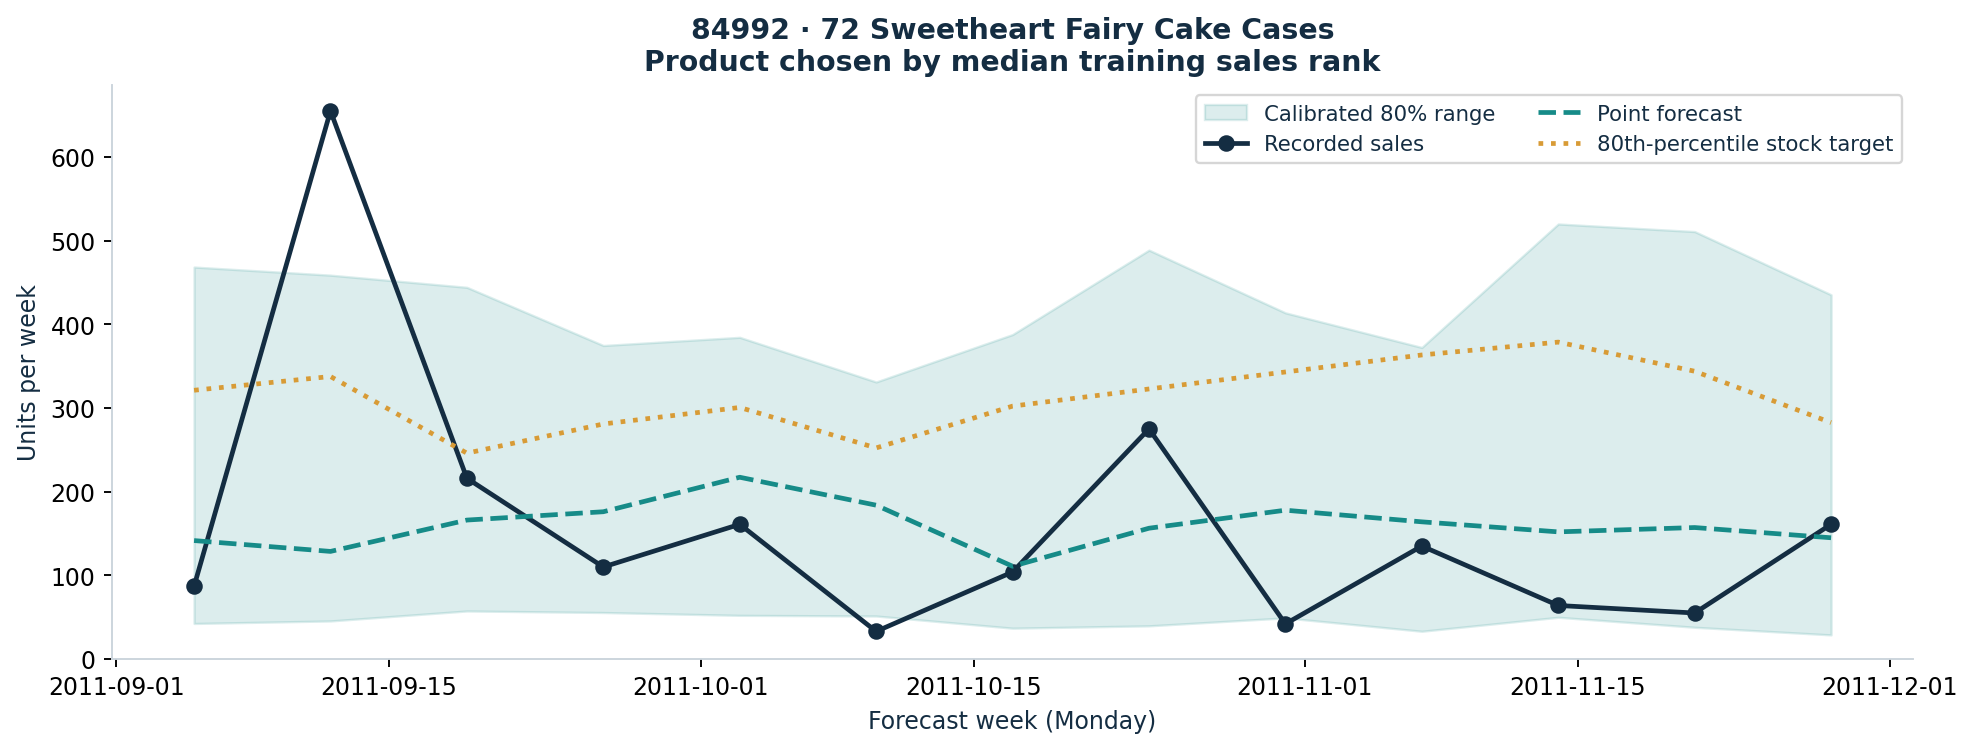

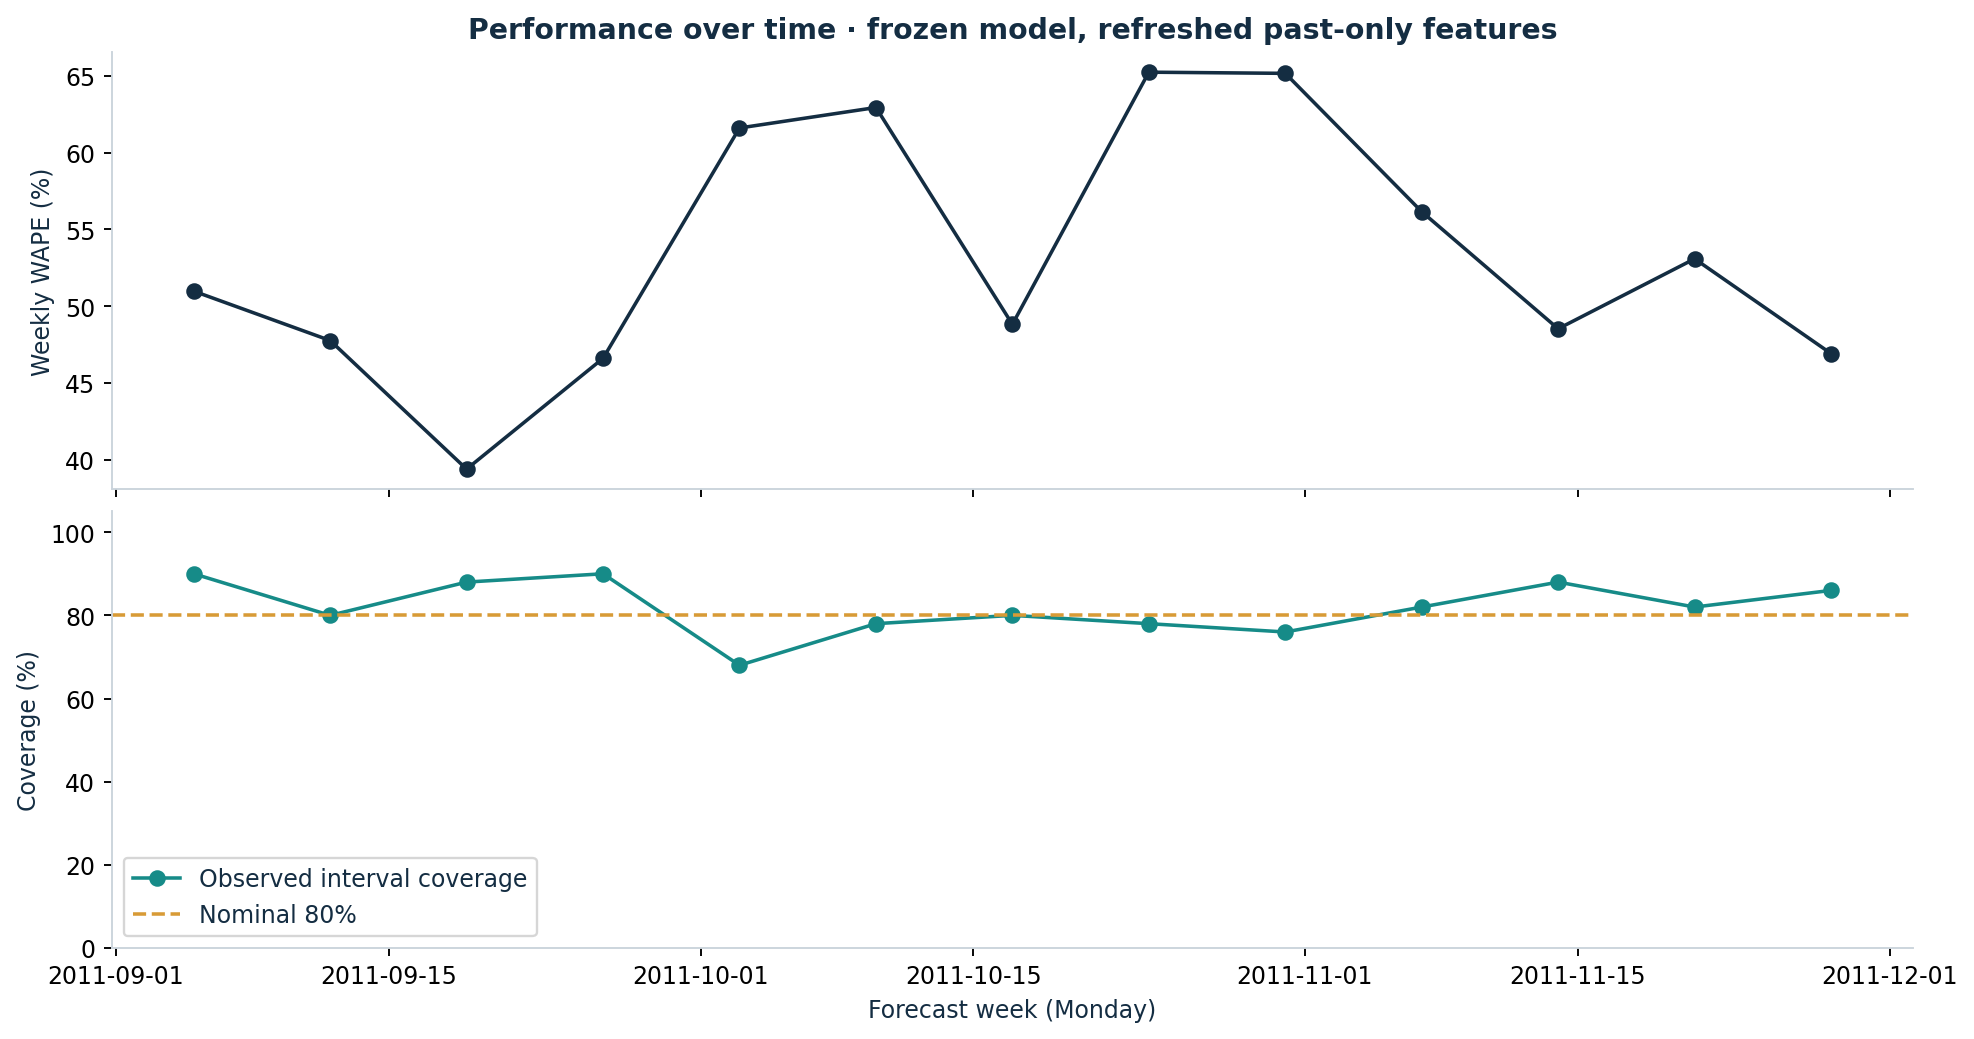

In [4]:
uncertainty = json.loads((output / "interval_metrics.json").read_text())
display(pd.DataFrame({k: uncertainty[k] for k in ("raw", "calibrated")}).T)
display(Image(filename=str(output / "forecast_example.png"), width=1000))
display(Image(filename=str(output / "weekly_monitoring.png"), width=1000))

## 4. Make the business loss explicit

This benchmark resets each product-week to zero stock and charges 4 scenario units for each missing unit and 1 for each excess unit. There is no lead time or carryover. An 80th-percentile target follows from the 4:1 underage-to-overage ratio. The baseline buffers are tuned on validation, not test data.

Quantile-policy cost reduction vs tuned mean baseline: 4.4%
Descriptive 95% block-bootstrap interval: ['-1.7%', '11.4%']
An interval spanning zero does not establish a reliable cost improvement.


,policy,total_cost,shortage_units,excess_units,fill_rate,shortage_week_fraction,mean_stock_target
0,mean4,356923.0,74587.0,58575.0,0.673221,0.435385,326.518462
1,mean4_tuned,323363.0,57265.0,94303.0,0.749112,0.318462,408.133846
2,point,398997.0,91975.0,31097.0,0.597041,0.469231,257.493846
3,point_tuned,331448.0,61760.0,84408.0,0.729418,0.283077,385.995385
4,quantile_80,309211.0,42614.0,138755.0,0.813300,0.184615,499.061538


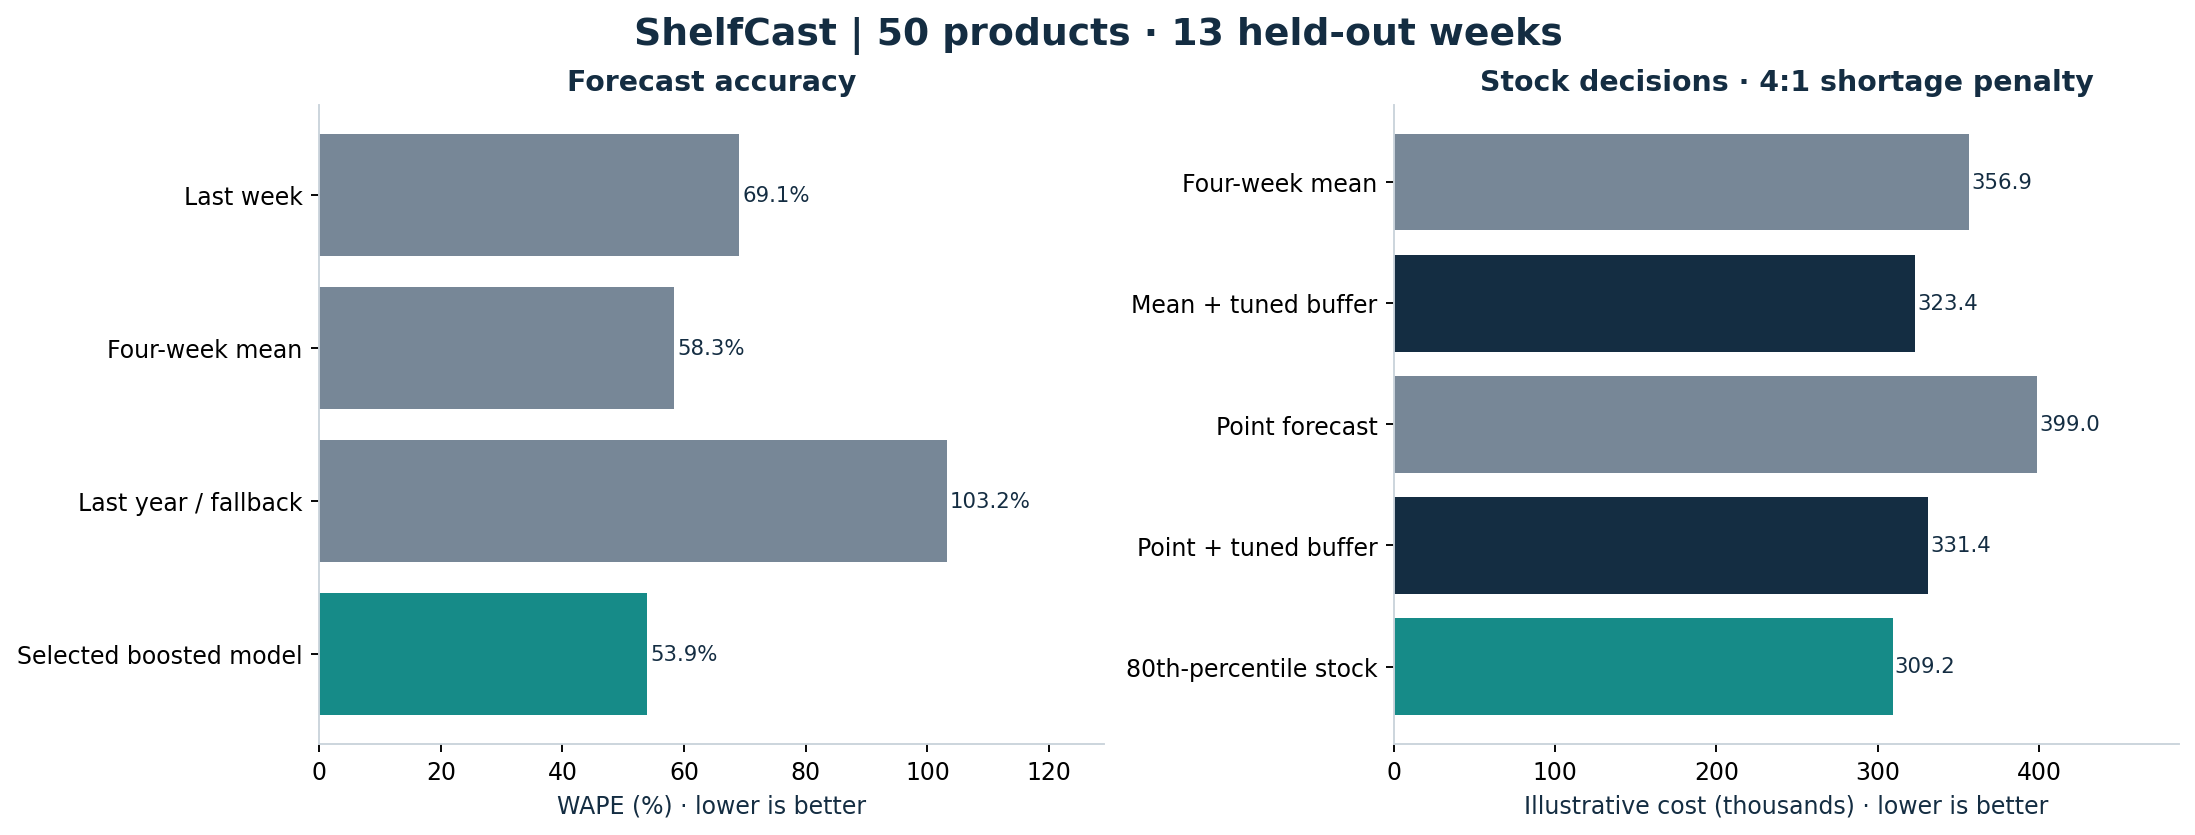

In [5]:
inventory = pd.read_csv(output / "inventory_metrics.csv")
display(inventory)
comparison = json.loads((output / "cost_bootstrap.json").read_text())
print(f"Quantile-policy cost reduction vs tuned mean baseline: {comparison['relative_cost_reduction']:.1%}")
print("Descriptive 95% block-bootstrap interval:", [f"{v:.1%}" for v in comparison["bootstrap_95_percentile_interval"]])
print("An interval spanning zero does not establish a reliable cost improvement.")
display(Image(filename=str(output / "benchmark.png"), width=1100))

## 5. Use the actual saved model through the API

The request uses a known product and 52 weeks of historical sales. The API calls the same feature builder as the offline experiment and refuses missing models, unknown products, or invalid chronology. It returns an order suggestion and does not execute a purchase.

In [6]:
from fastapi.testclient import TestClient
from shelfcast.api import create_app

request = json.loads((output / "example_request.json").read_text())
with TestClient(create_app(output / "model.joblib")) as client:
    assert client.get("/health").status_code == 200
    response = client.post("/forecast", json=request)
    assert response.status_code == 200, response.text
    result = response.json()
    assert result["suggested_order_units"] == max(0, result["stock_target_units"] - request["inventory_position"])
display(result)

{'sku': '84992',
 'forecast_week': '2011-09-05',
 'point_forecast_units': 141.56623515497776,
 'median_units': 151.75222190027677,
 'interval_80': {'lower': 42.498248230298174,
  'upper': 468.4235783470719,
  'interpretation': 'Empirically calibrated range; future coverage is not guaranteed.'},
 'stock_target_units': 322,
 'suggested_order_units': 302,
 'stock_rule': '80th percentile; illustrative underage:overage cost ratio 4:1, zero lead time',
 'recent_to_training_mean_ratio': 0.3737781903565773,
 'history_shift_warning': True,
 'model_id': 'a784cc857c7286e0'}

## Interpretation

The boosted model improves absolute forecast error but tends to underpredict high-volume weeks. Directly using that point estimate as stock leads to higher shortage cost. Quantile targets reduce that mismatch but require more excess stock.

The main contribution is a reproducible separation of **prediction, uncertainty, and decisions**, with evidence for each. Better real-world inventory recommendations would require stock availability, lead times, and additional seasons. See `docs/design.md` for assumptions and follow-up experiments.